In [1]:
import torch
import torchvision
import matplotlib.pyplot as plt

## MPSデバイスの利用

In [2]:
# 使えるか確認
torch.backends.mps.is_available()

True

In [3]:
# MPSの設定情報を作る
torch.device("mps")

device(type='mps')

In [4]:
# deviceの変数を定義
device = torch.device("mps")

## データの読み込み

In [5]:
# MNISTデータの読み込み
data = torchvision.datasets.MNIST("data", train=True, download=False)

## データの基本情報調査

In [6]:
type(data)

torchvision.datasets.mnist.MNIST

In [7]:
# 長さを調べる
len(data)

60000

In [8]:
# 1件だけ見る
data[0]

(<PIL.Image.Image image mode=L size=28x28>, 5)

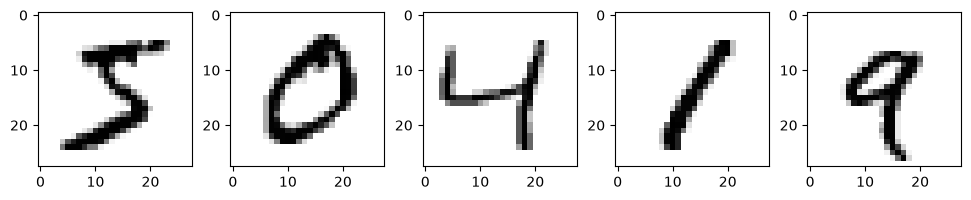

In [9]:
# 最初の5データを可視化する
fig, axs = plt.subplots(1, 5, figsize=(12, 2))

for i, ax in enumerate(axs):
    ax.imshow(data[i][0], cmap='gray_r')

plt.show()

In [10]:
# 形状を確認
data.data.shape

torch.Size([60000, 28, 28])

In [11]:
# 画素値の型
data.data.dtype

torch.uint8

In [12]:
# ラベルの形状
data.targets.shape

torch.Size([60000])

In [13]:
# ラベルのユニーク値確認
data.targets.unique()

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [14]:
# 画素値の範囲
data.data.min(), data.data.max()

(tensor(0, dtype=torch.uint8), tensor(255, dtype=torch.uint8))

In [15]:
# クラス名一覧
data.classes

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

## transformerを適用してのデータの再読み込み

In [16]:
transformer = torchvision.transforms.ToTensor()
train_ds = torchvision.datasets.MNIST(
    "data", 
    train=True, 
    download=False, 
    transform=transformer # transformを指定することでPIL.Imageからtensorへ変換
)
test_ds = torchvision.datasets.MNIST(
    "data", 
    train=False, 
    download=False, 
    transform=transformer
)

In [17]:
# データの確認
print(type(train_ds))
print(len(train_ds))
print(train_ds.data.shape)
print(train_ds.data.dtype)
print(train_ds.targets.shape)
print(train_ds.targets.unique())
print(train_ds.data.min(), train_ds.data.max())
print(train_ds.classes)

<class 'torchvision.datasets.mnist.MNIST'>
60000
torch.Size([60000, 28, 28])
torch.uint8
torch.Size([60000])
tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
tensor(0, dtype=torch.uint8) tensor(255, dtype=torch.uint8)
['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


In [18]:
# データの確認
print(type(test_ds))
print(len(test_ds))
print(test_ds.data.shape)
print(test_ds.data.dtype)
print(test_ds.targets.shape)
print(test_ds.targets.unique())
print(test_ds.data.min(), test_ds.data.max())
print(test_ds.classes)

<class 'torchvision.datasets.mnist.MNIST'>
10000
torch.Size([10000, 28, 28])
torch.uint8
torch.Size([10000])
tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
tensor(0, dtype=torch.uint8) tensor(255, dtype=torch.uint8)
['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


## DataLoaderでバッチ化

In [19]:
from torch.utils.data import DataLoader
batch_size = 32
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

In [20]:
# データの確認
print(type(train_dl))
print(len(train_dl))

<class 'torch.utils.data.dataloader.DataLoader'>
1875


In [21]:
images, labels = next(iter(train_dl))

# 形状確認
print(images.shape)
print(images.dtype)
print(images.min(), images.max())

torch.Size([32, 1, 28, 28])
torch.float32
tensor(0.) tensor(1.)


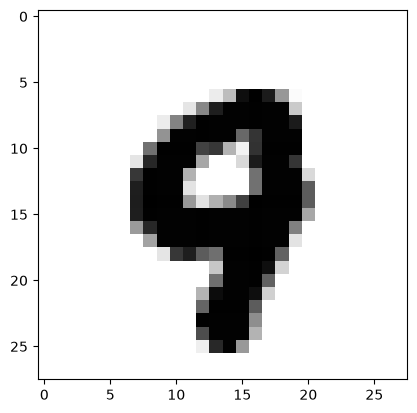

In [22]:
# 1枚取り出して描画
plt.imshow(images[0][0], cmap='gray_r')
plt.show()

## モデルの構築

In [23]:
import torch.nn as nn

# モデルを定義する（Flattenして総結合層を3回通すシンプルなネットワーク）
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.flat1 = nn.Flatten(1, -1)
        self.ln1 = nn.Linear(784, 256)
        self.ln2 = nn.Linear(256, 128)
        self.ln3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flat1(x)
        x = self.ln1(x)
        x = torch.relu(x)
        x = self.ln2(x)
        x = torch.relu(x)
        x = self.ln3(x)
        return x

In [24]:
# モデルのインスタンス化
model = Model().to(device)

# 損失関数の用意
criterion = nn.CrossEntropyLoss()

# オプティマイザの用意
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## トレーニング

In [25]:
# エポック数
num_epochs = 10

# トレーニング
for epoch in range(num_epochs):
    for images, labels in train_dl:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"epoch {epoch+1}, loss: {loss.item()}")

epoch 1, loss: 0.0990537703037262
epoch 2, loss: 0.17054784297943115
epoch 3, loss: 0.038841720670461655
epoch 4, loss: 0.0031619518995285034
epoch 5, loss: 0.08615805208683014
epoch 6, loss: 0.04078688845038414
epoch 7, loss: 0.1417875438928604
epoch 8, loss: 0.0488271489739418
epoch 9, loss: 0.004779760725796223
epoch 10, loss: 9.33044939301908e-05


## テスト用データで試験

In [26]:
# テストデータのDataLoaderを準備
test_dl = DataLoader(test_ds, batch_size=1000, shuffle=False)

In [27]:
# モデルを評価モードに
model.eval()
correct = 0
total = 0

# テストデータで予測・評価
with torch.no_grad():
    for images, labels in test_dl:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        predicted = torch.argmax(outputs, dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"accuracy: {accuracy:.4f}")

accuracy: 0.9799
